 #  Coffee Shop Sales Analysis  

##  Опис проєкту
Мета проєкту — проаналізувати дані продажів мережі кав’ярень, виявити ключові тенденції та фактори, що впливають на виручку.  
Аналіз допоможе відповісти на такі питання:  
- які товари та категорії найбільш популярні
- яка динаміка продажів за весь період  
- як змінюються продажі протягом дня та тижня та часу доби  
- які локації приносять найбільший дохід  
- який середній чек і скільки товарів зазвичай купують у транзакції

Отримані інсайти будуть візуалізовані у вигляді інтерактивного дашборду в Tableau.  

---

##  Опис даних
Датасет містить транзакції кав’ярень із такими змінними:  

- `transaction_id` — унікальний ідентифікатор транзакції  
- `transaction_date` — дата покупки  
- `transaction_time` — час покупки  
- `transaction_qty` — кількість товарів у транзакції  
- `store_id` — ID магазину  
- `store_location` — місто/локація кав’ярні  
- `product_id` — ID продукту  
- `unit_price` — ціна за одиницю  
- `product_category` — категорія продукту (кава, чай, випічка тощо)  
- `product_type` — підкатегорія продукту  
- `product_detail` — детальний опис продукту  

---

##  Джерело даних
Дані взяті з [Kaggle](https://www.kaggle.com/) (Coffee Shop Sales Dataset).  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Для початку завантажимо дані та ознайомимось з їх структурою (кількість рядків та колонок, типи даних, наявність пропущених значень та дуплікатів

In [2]:
df = pd.read_excel(r"D:\Навчання\Data Analytics\КУРС DATA ANALIST\data for traning\Coffee Shop Sales.xlsx")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
df.shape

(149116, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [5]:
df.isna().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [6]:
df.duplicated().any()

np.False_

In [7]:
# Базова статистика для числових колонок
df[['transaction_qty', 'unit_price']].describe()

,transaction_qty,unit_price
count,149116.000000,149116.000000
mean,1.438276,3.382219
std,0.542509,2.658723
min,1.000000,0.800000
25%,1.000000,2.500000
50%,1.000000,3.000000
75%,2.000000,3.750000
max,8.000000,45.000000


### Огляд описової статистики та викидів

Стандартне відхилення transaction_qty досить низьке **(0,54)**, що означає, що більшість клієнтів зазвичай купують лише 1–2 товари за транзакцію.
Натомість, unit_price показує набагато вище стандартне відхилення **(2,66)** відносно свого середнього значення (3,38), що вказує на велику різницю в цінах на продукцію.
Цей розкид може відображати наявність потенційних викидів.

Розглянемо максимальні значення для додаткового розуміння:

Максимальна кількість транзакцій становить **8** товарів за одну покупку. Оскільки більшість транзакцій складають 1–2 товари, це незвично, але все ж реалістично (наприклад, групове замовлення).
Максимальна ціна за одиницю становить **45**, тоді як 75-й процентиль становить лише 3,75. Ця різка різниця викликає підозру щодо викидів і вимагає глибшого дослідження.

Щоб краще зрозуміти ці закономірності та виявити можливі аномалії, ми візуалізуємо розподіли за допомогою гістограм та коробкових діаграм.


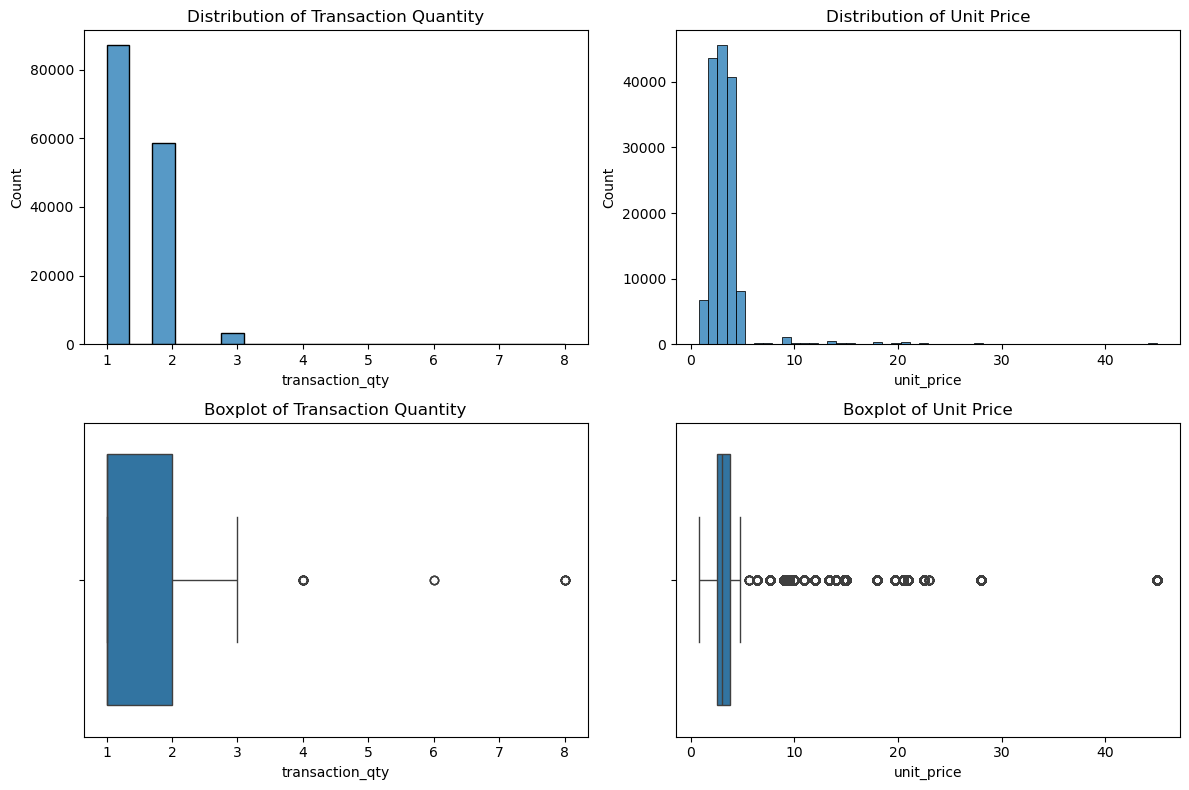

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Distribution of transaction quantity
sns.histplot(df['transaction_qty'], bins=20, ax=axes[0,0])
axes[0,0].set_title("Distribution of Transaction Quantity")

sns.boxplot(x=df['transaction_qty'], ax=axes[1,0])
axes[1,0].set_title("Boxplot of Transaction Quantity")

# Distribution of unit price
sns.histplot(df['unit_price'], bins=50, ax=axes[0,1])
axes[0,1].set_title("Distribution of Unit Price")

sns.boxplot(x=df['unit_price'], ax=axes[1,1])
axes[1,1].set_title("Boxplot of Unit Price")

plt.tight_layout()
plt.show()

## Аналіз потенційних аутлаєрів

Щоб перевірити, чи найвищі ціни є викидами, чи преміальними продуктами, ми перевіримо 10 найдорожчих товарів та перевіримо їхні `product_id`, `product_category`, `product_type` та `product_detail`.
Якщо ці продукти постійно відображаються за однаковою ціною, це означає, що вони є реальними  продуктами, а не помилками.

In [9]:
# Toп-10 за ціною
df.sort_values(by="unit_price", ascending=False).head(10)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
64745,64915,2023-04-12,16:44:10,1,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat
125082,125419,2023-06-10,15:52:18,1,5,Lower Manhattan,8,45.0,Coffee beans,Premium Beans,Civet Cat
136500,136837,2023-06-20,07:50:58,1,3,Astoria,8,45.0,Coffee beans,Premium Beans,Civet Cat
136393,136730,2023-06-19,19:37:12,1,3,Astoria,8,45.0,Coffee beans,Premium Beans,Civet Cat
8443,8473,2023-01-15,18:18:51,1,3,Astoria,8,45.0,Coffee beans,Premium Beans,Civet Cat
8473,8503,2023-01-15,19:37:12,1,3,Astoria,8,45.0,Coffee beans,Premium Beans,Civet Cat
64674,64844,2023-04-12,15:16:12,1,5,Lower Manhattan,8,45.0,Coffee beans,Premium Beans,Civet Cat
96311,96565,2023-05-15,18:18:51,1,3,Astoria,8,45.0,Coffee beans,Premium Beans,Civet Cat
30357,30414,2023-02-23,09:25:03,1,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat
48232,48339,2023-03-21,20:52:55,1,8,Hell's Kitchen,8,45.0,Coffee beans,Premium Beans,Civet Cat


In [10]:
# Toп-10 продуктів за максимальною ціною
df.groupby(['product_id', 'product_category', 'product_type', 'product_detail'])['unit_price'] \
  .max().sort_values(ascending=False).head(10)

product_id  product_category  product_type       product_detail           
8           Coffee beans      Premium Beans      Civet Cat                    45.00
9           Coffee beans      Organic Beans      Organic Decaf Blend          28.00
81          Branded           Clothing           I Need My Bean! T-shirt      28.00
82          Branded           Housewares         I Need My Bean! Diner mug    23.00
83          Branded           Housewares         I Need My Bean! Latte cup    23.00
6           Coffee beans      Gourmet Beans      Ethiopia                     21.00
4           Coffee beans      Espresso Beans     Primo Espresso Roast         20.45
7           Coffee beans      Premium Beans      Jamacian Coffee River        19.75
2           Coffee beans      House blend Beans  Our Old Time Diner Blend     18.00
1           Coffee beans      Organic Beans      Brazilian - Organic          18.00
Name: unit_price, dtype: float64

In [11]:
# Toп-10 продуктів за максимальною кількістю
df.groupby(['product_id', 'product_category', 'product_type', 'product_detail'])['transaction_qty'] \
  .max().sort_values(ascending=False).head(10)

product_id  product_category  product_type           product_detail             
8           Coffee beans      Premium Beans          Civet Cat                      8
82          Branded           Housewares             I Need My Bean! Diner mug      6
83          Branded           Housewares             I Need My Bean! Latte cup      4
65          Flavours          Sugar free syrup       Sugar Free Vanilla syrup       4
64          Flavours          Regular syrup          Hazelnut syrup                 4
63          Flavours          Regular syrup          Carmel syrup                   4
41          Coffee            Barista Espresso       Cappuccino Lg                  4
26          Coffee            Organic brewed coffee  Brazilian Rg                   3
23          Coffee            Drip coffee            Our Old Time Diner Blend Rg    3
22          Coffee            Drip coffee            Our Old Time Diner Blend Sm    3
Name: transaction_qty, dtype: int64

Найвищі ціни відповідають преміальним кавовим зернам та брендованим товарам, що підтверджує наявність асортименту з широким ціновим діапазоном, а не помилки в даних.
Велика кількість одиниць товарув одному чеку також має сенс для цих товарів, відображаючи гуртові покупки.  

Загалом, ні високі ціни, ні великі обсяги не є викидами,  вони відображають реальну поведінку клієнтів та різноманітність продукції.

## Перетворення типів даних  

Для зручності при групуванні та оптимізації пам'яті перетворимо у категоріальні змінні колонки product_category, product_type, product_detail та store_location

In [12]:
categorical_cols = ['product_category', 'product_type', 'product_detail', 'store_location']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location            category
product_id                   int64
unit_price                 float64
product_category          category
product_type              category
product_detail            category
dtype: object

Для подальших розрахунків витягнемо з дати наступні змінні:  
- рік, місяць, день    
- день тижня (weekday)  
- годину, щоб проаналізувати час покупки

In [13]:
import warnings
warnings.filterwarnings('ignore')

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day'] = df['transaction_date'].dt.day
df['weekday'] = df['transaction_date'].dt.day_name()

df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time
df['hour'] = pd.to_datetime(df['transaction_time'].astype(str)).dt.hour

## Аналіз продажів
Розрахуємо суму по кожній транзакції. 

Подивимось продажі по місяцях, локаціях та топ категорії

In [14]:
# Сума за транзакцію
df['total_price'] = df['transaction_qty'] * df['unit_price']


In [15]:
# Продажі по місяцях
df.groupby('month')['total_price'].sum()

month
1     81677.74
2     76145.19
3     98834.68
4    118941.08
5    156727.76
6    166485.88
Name: total_price, dtype: float64

In [16]:
# Продажі по магазинах / локаціях: 
df.groupby('store_location')['total_price'].sum().sort_values(ascending=False)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: total_price, dtype: float64

In [17]:
# Продажі по категоріях товарів: 
df.groupby('product_category')['total_price'].sum().sort_values(ascending=False)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: total_price, dtype: float64

In [18]:
# Продажі по категоріях товарів за кількістю проданих одиниць: 
df.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False)

product_category
Coffee                89250
Tea                   69737
Bakery                23214
Drinking Chocolate    17457
Flavours              10511
Coffee beans           1828
Loose Tea              1210
Branded                 776
Packaged Chocolate      487
Name: transaction_qty, dtype: int64

In [19]:
pivot_store_month = df.pivot_table(
    index='store_location',
    columns='month',
    values='total_price',
    aggfunc='sum'
)

pivot_store_month

month,1,2,3,4,5,6
store_location,,,,,,
Astoria,27313.66,25105.34,32835.43,39477.61,52428.76,55083.11
Hell's Kitchen,27820.65,25719.80,33110.57,40304.14,52598.93,56957.08
Lower Manhattan,26543.43,25320.05,32888.68,39159.33,51700.07,54445.69


З наших розрахунків бачимо позитивну тенденцію продажів по місяцям. Було невелике просідання в лютому, але вже в березні був відчутний приріст і позитивна тенденція збереглась. Також слід зазначити, що зростання є рівномірним по всім точкам продажів. Hell's Kitchen є лідером продажів, але розриви між локаціями не значні. 

Серед категорій лідерами продажів є Coffee, Tea та Bakery. 

## Середній чек  
Перевіримо, чи є в датасеті мульти-рядкові транзакції. Це допоможе правильно розрахувати середній чек.  
Також розрахуємо середній чек для всієї мережі та середній чек помісячно для кожної кав'ярні, візуалізуємо результати

In [20]:
tx_counts = df.groupby('transaction_id').size()

multi_line_exist = (tx_counts > 1).any()
print("Чи є транзакції на більше ніж один рядок?", multi_line_exist)

Чи є транзакції на більше ніж один рядок? False


In [21]:
avg_check_total = df['total_price'].mean()
print(f"Середній чек по мережі: {avg_check_total:.2f}")


Середній чек по мережі: 4.69


In [22]:
# Середній чек по кожній кав'ярні
avg_check_by_store = df.groupby('store_location')['total_price'].mean().round(2)
print(avg_check_by_store)


store_location
Astoria            4.59
Hell's Kitchen     4.66
Lower Manhattan    4.81
Name: total_price, dtype: float64


In [23]:
monthly_avg_check = (
    df.groupby(['month', 'store_location'])
      .agg(avg_check=('total_price', 'mean'))
      .reset_index()
)

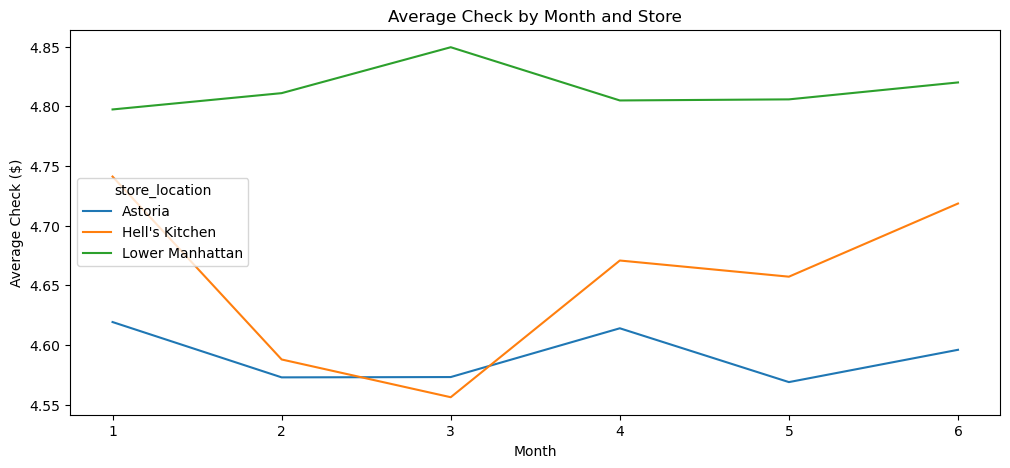

In [24]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_avg_check,
    x='month',
    y='avg_check',
    hue='store_location',
    markers=True
)
plt.title("Average Check by Month and Store")
plt.xlabel("Month")
plt.ylabel("Average Check ($)")
plt.show()


З графіку бачимо, що найвищий середній чек в кав'ярні на Lower Manhattan, а найнижчий в Astoria.  
В кав'ярні на Hell`s Kitchen видно просідання середнього чеку в лютому й березні, але з квітня ситуація покращилась і стабілізувалась

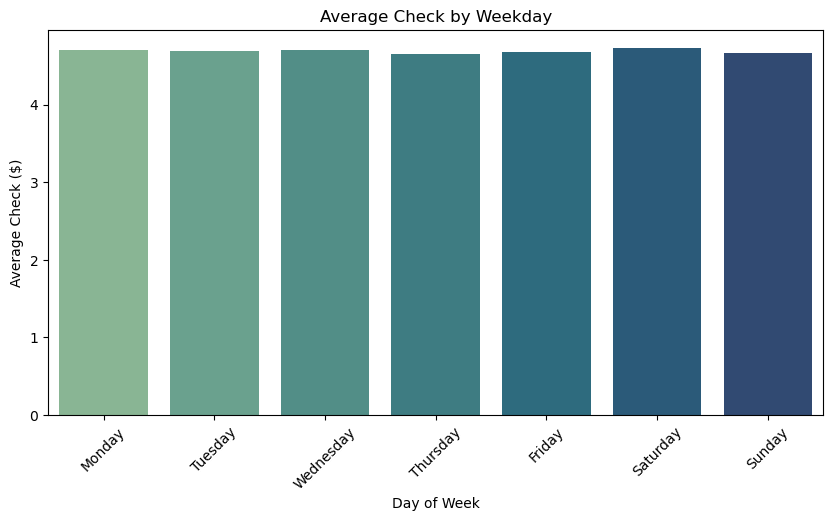

In [25]:
# Розрахунок середнього чеку за днями тижня
avg_check_by_weekday = (
    df.groupby('weekday')['total_price']
    .mean()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

# Побудова графіка
plt.figure(figsize=(10,5))
sns.barplot(x=avg_check_by_weekday.index, y=avg_check_by_weekday.values, palette="crest")

plt.title("Average Check by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Average Check ($)")
plt.xticks(rotation=45)
plt.show()


## Аналіз продажів

Проаналізуємо детально продажі мережі кав'ярень.  
Для початку поглянемо на динаміку щоденних продажів.

In [26]:
# Агрегуємо дані по днях
daily = (
    df.groupby('transaction_date')
    .agg(total_sales=('total_price', 'sum'))  # сума продажів за день
    .reset_index()
    .set_index('transaction_date')
)

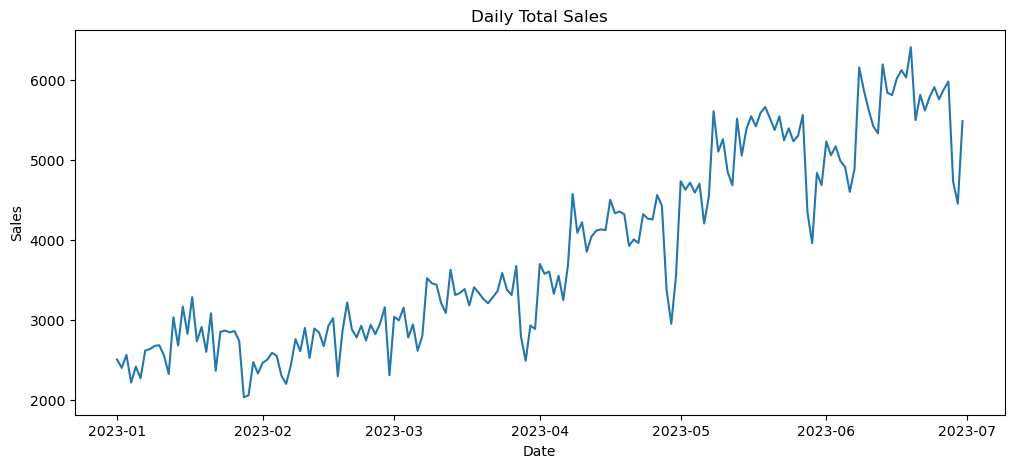

In [27]:
# Щоденний обсяг продажів
plt.figure(figsize=(12,5))
sns.lineplot(data=daily, x=daily.index, y='total_sales')
plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

На графіку бачимо чітку тенденцію до збільшення продажів. Проте видно також точки екстреммального падіння. Потрібно проаналізувати додатково, що це за дні тижня і чи є якась закономірність в цих падіннях.  

Перевіримо травень - тут досить різке падіння.

In [28]:
# Вибираємо тільки травень
may = df[df['transaction_date'].dt.month == 5]

# Групуємо по датах та підраховуємо кількість транзакцій на кожен день
daily_may = may.groupby('transaction_date')['transaction_id'].nunique().sort_index()

print(daily_may)


transaction_date
2023-05-01    1050
2023-05-02    1040
2023-05-03    1076
2023-05-04    1029
2023-05-05    1062
2023-05-06     955
2023-05-07    1012
2023-05-08    1186
2023-05-09    1094
2023-05-10    1163
2023-05-11    1067
2023-05-12    1040
2023-05-13    1148
2023-05-14    1071
2023-05-15    1156
2023-05-16    1219
2023-05-17    1014
2023-05-18    1192
2023-05-19    1214
2023-05-20    1166
2023-05-21    1053
2023-05-22    1117
2023-05-23    1075
2023-05-24    1104
2023-05-25    1043
2023-05-26    1089
2023-05-27    1183
2023-05-28     999
2023-05-29     906
2023-05-30    1022
2023-05-31     982
Name: transaction_id, dtype: int64


In [29]:
# Групуємо по датах і підраховуємо суму продажів на кожен день
daily_sales_may = may.groupby('transaction_date')['total_price'].sum().sort_index()

print(daily_sales_may)

transaction_date
2023-05-01    4731.45
2023-05-02    4625.50
2023-05-03    4714.60
2023-05-04    4589.70
2023-05-05    4701.00
2023-05-06    4205.15
2023-05-07    4542.70
2023-05-08    5604.21
2023-05-09    5100.97
2023-05-10    5256.33
2023-05-11    4850.06
2023-05-12    4681.13
2023-05-13    5511.53
2023-05-14    5052.65
2023-05-15    5384.98
2023-05-16    5542.13
2023-05-17    5418.00
2023-05-18    5583.47
2023-05-19    5657.88
2023-05-20    5519.28
2023-05-21    5370.81
2023-05-22    5541.16
2023-05-23    5242.91
2023-05-24    5391.45
2023-05-25    5230.85
2023-05-26    5300.95
2023-05-27    5559.15
2023-05-28    4338.65
2023-05-29    3959.50
2023-05-30    4835.48
2023-05-31    4684.13
Name: total_price, dtype: float64


Бачимо найнижчі показники продажів за 29 травня 2023 року.  
29 травня 2023 року в США відзначався Memorial Day — національне свято, яке припадає на останній понеділок травня. Це день вшанування пам'яті американських військовослужбовців, які загинули під час служби в збройних силах США. 

Падіння продажів  може бути пов'язано з тим, що багато магазинів і підприємств були зачинені або працювали в скороченому режимі через святкування Memorial Day.

Далі подивимось на продажі в розрізі годин

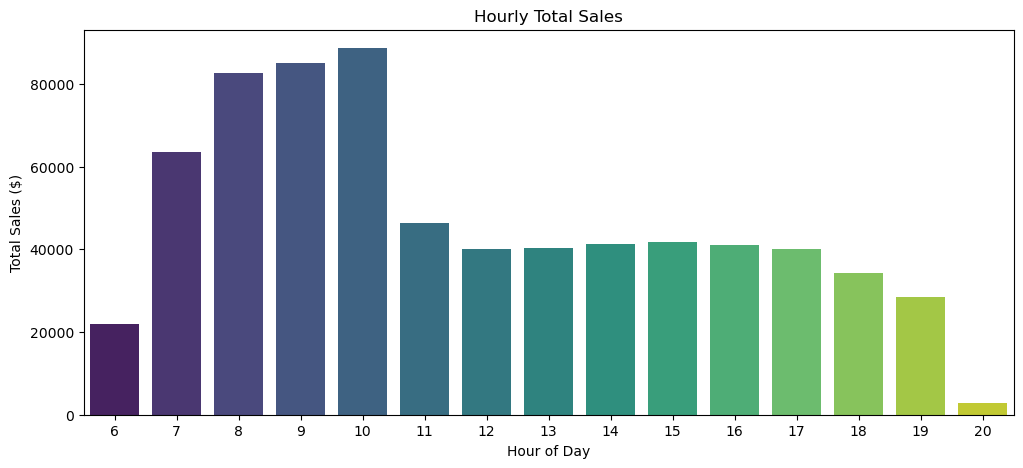

In [30]:
# Агрегуємо загальні продажі по годинах
hourly_sales = df.groupby('hour')['total_price'].sum()

# Bar plot
plt.figure(figsize=(12,5))
sns.barplot(x=hourly_sales.index, y=hourly_sales.values, palette="viridis")
plt.title("Hourly Total Sales")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales ($)")
plt.show()


Бачимо пік продажів в ранкові години, що характерно для кав'ярні. Після 10ї години спостерігаємо спад продажів з сталим клієнтопотоком. Найнижчі продажі о 20й годині, що також цілком природньо для такого закладу.  

Порівняємо погодинні продажі для всієї мережі кав'ярень.

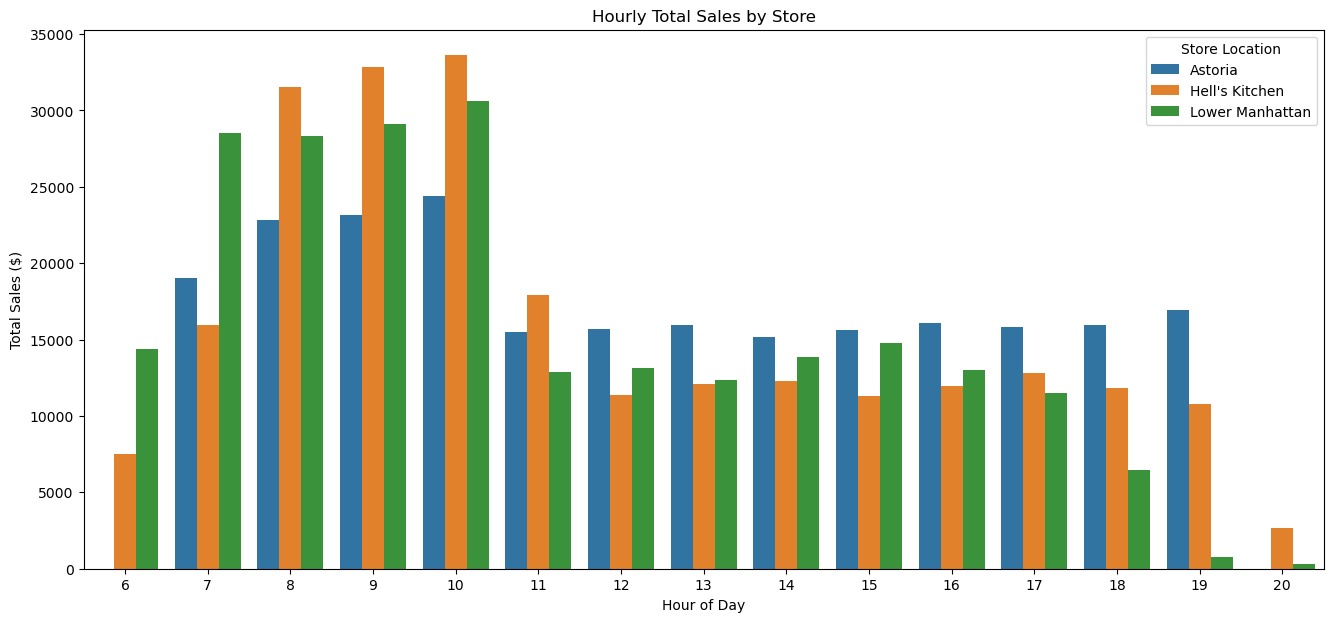

In [31]:
# Агрегуємо загальні продажі по годинах та кав'ярнях
hourly_store_sales = df.groupby(['hour', 'store_location'])['total_price'].sum().reset_index()

plt.figure(figsize=(16,7))  # збільшене полотно
sns.barplot(
    data=hourly_store_sales,
    x='hour',
    y='total_price',
    hue='store_location',
    palette='tab10'
)

plt.title("Hourly Total Sales by Store")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales ($)")
plt.legend(title="Store Location")
plt.show()

### Погодинні продажі по кав'ярням

1️⃣ Astoria - переважно житловий район з високою щільністю населення.
З візуалізації можемо зробити висновок, що графік роботи кав'ярні 7:00 – 19:00.

Особливості продажів:
Ранкові години (7–10 ранку) демонструють суттєвий потік покупців.
Денні та вечірні години (12–19) показують найвищі продажі по всій мережі.
Доцільно переглянути графік роботи, можна протестувати графік з 6:00 до 20:00 протягом місяця і на основі продажів прийняти рішення про зміну графіку роботи.

2️⃣ Hell’s Kitchen (Пекельна кухня) – район із великою концентрацією офісів, ресторанів та готелів.
Режим роботи кав'ярні 6:00 – 20:00.

Особливості продажів:
6–7 ранку – найнижчі показники по мережі
8–11 – пікові продажі (найвищі по мережі).
Вдень – показники часто нижчі по мережі.


3️⃣ Lower Manhattan (Нижній Манхеттен) – фінансовий і бізнес-центр міста, велика концентрація офісів та корпоративних клієнтів.
Режим роботи кав'ярні 6:00 – 20:00.

Особливості продажів:
7–10 ранку – високі показники (7 ранку – найвищі по всій мережі).
Вдень – очікуване зниження продажів.
19–20 вечора – дуже низькі показники, можливо, продажі в ці години неефективні.
Вечірній попит мінімальний, оскільки люди покидають офіси і район стає малонаселеним. Можливо доцільно переглянути режим роботи після 18:00.

Слід оптимізувати години роботи спираючись на результати аналізу


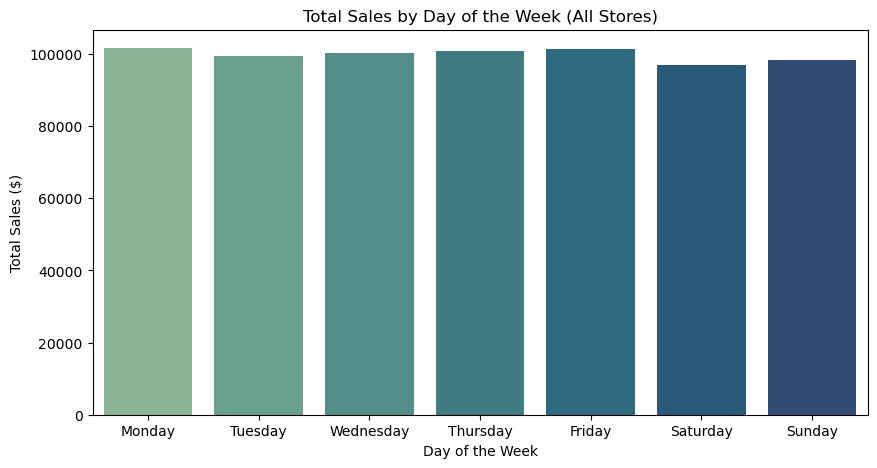

In [32]:
# Загальні продажі по дням тижня
weekday_sales = (
    df.groupby('weekday')['total_price']
    .sum()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette="crest")
plt.title("Total Sales by Day of the Week (All Stores)")
plt.xlabel("Day of the Week")
plt.ylabel("Total Sales ($)")
plt.show()



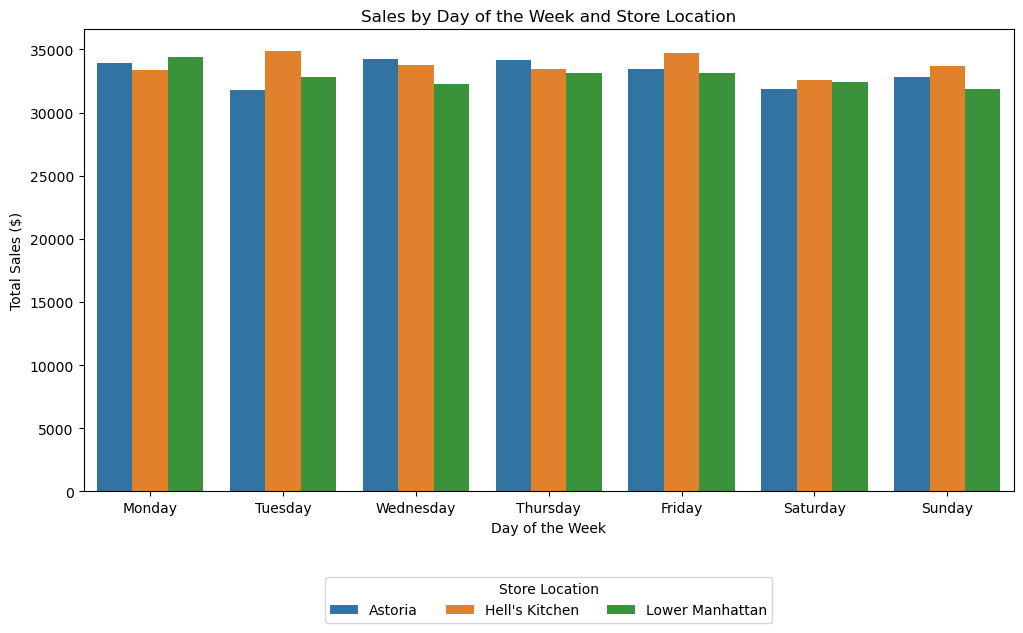

In [33]:
weekday_store_sales = (
    df.groupby(['store_location', 'weekday'])['total_price']
    .sum()
    .reset_index()
)

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12,6))
sns.barplot(
    data=weekday_store_sales,
    x='weekday',
    y='total_price',
    hue='store_location',
    order=order,
    palette='tab10'
)
plt.title("Sales by Day of the Week and Store Location")
plt.xlabel("Day of the Week")
plt.ylabel("Total Sales ($)")
plt.legend(title="Store Location", loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.show()


Аналіз продажів по днях тижня показує стабільну картину: значних коливань немає, попит розподілений рівномірно.

У розрізі магазинів тенденція аналогічна — всі локації демонструють рівномірні продажі протягом тижня. Це свідчить про стабільну активність клієнтів і спрощує планування роботи мережі.

Для подальшого аналізу збережемо файл в csv форматі та перейдемо в Tableau для побудови дашборду 

In [34]:
df.to_csv("coffee_sales.csv", index=False)


**ВИСНОВКИ**

**Загальна динаміка продажів**  
Продажі в мережі кав’ярень загалом демонструють стабільну активність із незначними коливаннями. Незначні зниження збігалися з вихідними або святковими днями (зокрема, Memorial Day у травні).

**Погодинний розподіл продажів**  
Найвищі продажі спостерігаються в ранкові години (7:00–10:00) — період, коли люди купують каву по дорозі на роботу.
У другій половині дня продажі поступово знижуються, але деякі локації мають вечірні піки (17:00–20:00) — це може бути пов’язано з відпочинком або вечірніми зустрічами.

**Особливості локацій**  
Astoria — активна зранку, з найвищими вечірніми продажами по мережі; це може свідчити про локальний попит мешканців району.  
Hell’s Kitchen — найвищі показники з 8:00 до 11:00, типово для бізнес-районів із великою кількістю офісів.  
Lower Manhattan — високі продажі у ранкові години (пік о 7:00), після чого спостерігається спад; вечірня активність мінімальна, можливо, через орієнтацію району на офісних працівників.

**Середній чек**  
Середній чек по мережі стабільний за днями тижня. Lower Manhattan показує незначну перевагу в показниках середнього чеку.

**Категорії товарів**  
Основну частку продажів формує кава та чай, далі - випічка, що підтверджує ключову роль класичних позицій у прибутку кав’ярень.  
Водночас, інші категорії хоча й не входять до топу за обсягом продажів, відіграють важливу роль в асортименті — вони розширюють вибір для клієнтів, підвищують середній чек. Рекомендовано підтримувати баланс між основними та додатковими категоріями, розвиваючи додаткові пропозиції. 


**📈 РЕКОМЕНДАЦІЇ**

**Оптимізація графіку роботи**  
У Lower Manhattan можна розглянути скорочення робочих годин у вечірній час.  
У Astoria доцільно переглянути графік загалом і протестувати режим роботи з 6.00 до 20.00. Доцільно забезпечити кав'ярню додатковим персоналом.

**Маркетингові можливості**  
Розробити ранкові комбо-пропозиції (кава + випічка) для мережі в цілому.  
Ввести вечірні знижки на десерти або "second coffee" акції.  
Можливо розробити персоналізовані акції під конкретні кав'ярні.

**Продуктовий асортимент**  
Розширити меню найпопулярніших категорій — кавових напоїв, чаю та випічки.    
Ввести сезонні напої або обмежені пропозиції (наприклад, cold brew улітку) для стимулювання повторних покупок.

**Подальший моніторинг**  
Відстежувати показники середнього чеку й продажів після змін у графіку чи меню.  
Продовжувати збирати дані та порівнювати показники від місяця до місяця, за півряччя, щоб мати більш повну картину для прийняття рішень.